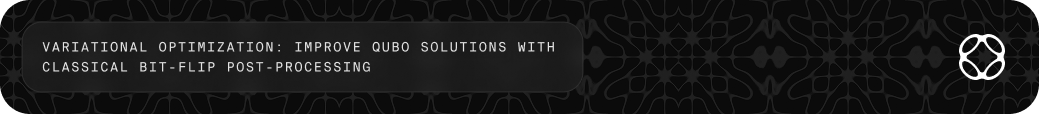

This notebook demonstrates how to use `haiqu.postprocess()` to improve optimization results through classical post-processing.

- For a 120-qubit QUBO problem, **without post-processing we find a suboptimal solution**.
- With post-processing, we achieve **the optimal solution**—no additional quantum circuit runs required.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `haiqu.postprocess()`

- **What does it do?** Applies classical heuristics (e.g., bit-flip search) to measured bitstrings to find a better solution to the QUBO problem.
- **How do I use it?** Pass counts or probability distribution obtained by running circuits on any backend, and pass the corresponding QUBO problem object, then call `postprocess()`.
- **What are the options?**
  - `postprocess_iterations` (default 5) – controls the number of optimization passes.
  - `seed` (optional) – set for reproducible post-processing results.
- **Which options do you recommend?** Start with lowest `postprocess_iterations=1`; increase to 10 to see how it improves the solution quality. Set `seed` (e.g., `seed=34`) when you need reproducible post-processing results.

## Initialize the benchmark

Import the necessary libraries, initialize the Haiqu SDK, and load a 120-qubit QUBO problem.  We'll compare raw quantum results against post-processed results.

In [1]:
import json
import numpy as np
import pandas as pd
from haiqu.sdk import haiqu
from haiqu.sdk.optimization import QUBO

# Set pandas display options to show full column width
pd.set_option('display.max_colwidth', None)

haiqu.login()
haiqu.init("QUBO Postprocessing Tutorial")

# Load QUBO problem from CPLEX file
cplex_file = "graph_optimization_120q/seq_6434_c.lp"
optimization_problem = QUBO.from_file(cplex_file)

# Load pre-generated quantum samples. 
# This is output of a VQE trained on an optimization problem with 120 qubits.
# Note that counts use qiskit's bitstring convention where bitstring with key '01' means qubit 0 is in state |1> and qubit 1 is in state |0>.
filename = "graph_optimization_120q/mps_counts_trained.json"
with open(filename, "r") as file:
    raw_counts = json.load(file)

## Run benchmark scenarios

Run experiments comparing raw quantum results and post-processed results on a 120-qubit optimization problem (can take few minutes to run)

In [2]:
# Initialize scenarios
scenarios = [
    {"postprocess": False, "description": "Raw Quantum Results"},
    {"postprocess": True,  "description": "With Postprocessing"}
]


# Loop over scenarios and collect results
results = []
for scenario in scenarios:
    
    # Get counts
    counts = raw_counts
    
    # Apply postprocessing if requested
    if scenario["postprocess"]:
        costs, counts = haiqu.postprocess(
            counts=raw_counts,
            problem=optimization_problem,
            postprocess_iterations = 10,
            seed=34
        )
    else:
        costs = {
            bitstring: optimization_problem.cost(bitstring)
            for bitstring in counts.keys() 
        }
    
    # Find best solution
    best_cost = min(costs.values())
    
    # Store results for summary table
    results.append({"cost": best_cost, "description": scenario["description"]})

Post-processing significantly improves solution quality. Summary of results:

In [3]:
# baseline optimal solution: note that we always use the qiskit's little-endian convention for bitstrings where for example '01' means q1=0 and q0=1.
optimal_bitstring = '000000000000001001001000000000000000000000100100010010001000100000000000000000000001000100000100000000000010000000000000'

optimal_cost = optimization_problem.cost(optimal_bitstring) 
print(f"True optimal cost: {optimal_cost:.2f}\n")

def build_summary(results):
    """Build summary table data from experiment results."""
    # Calculate normalized approximation ratios with interpretation
    normalized_approx_ratios = []
    
    for r in results:
        gap = (r["cost"] - optimal_cost) / abs(optimal_cost)
        # ρ = 1 + (f(x) - f*) / |f*|

        ratio = 1 + gap
        
        if gap < 1e-6:
            ratio_with_interpretation = f"{ratio:.4f} (Optimal)"
        else:
            ratio_with_interpretation = f"{ratio:.4f} ({gap*100:.1f}% worse than optimal)"
        
        normalized_approx_ratios.append(ratio_with_interpretation)
    
    return {
        'Configuration': [r["description"] for r in results],
        'Best Cost': [f'{r["cost"]:.2f}' for r in results],
        'Normalized Approximation Ratio': normalized_approx_ratios,
        'Business Impact': [
            'Baseline quantum sampling provides sub-optimal initial solutions',
            'Post-processing finds the optimal solution at no extra quantum cost',
        ]
    }

pd.DataFrame(build_summary(results))

True optimal cost: -209.40



,Configuration,Best Cost,Normalized Approximation Ratio,Business Impact
0,Raw Quantum Results,-0.70,1.9967 (99.7% worse than optimal),Baseline quantum sampling provides sub-optimal initial solutions
1,With Postprocessing,-209.40,1.0000 (Optimal),Post-processing finds the optimal solution at no extra quantum cost


> **💡 Good to Know:** [Post-processing techniques](https://docs.haiqu.ai/core_features/postprocessing) work with counts from any backend and use only classical compute at no extra quantum cost.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

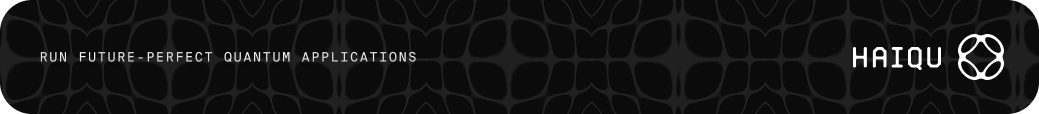